# 05. Revenue and expenditure decomposition

Move from B.9 levels to the exact identity B = R - E, and decompose each adjacent-year balance change into a revenue change and an expenditure change.

**Reads**

- `data/processed/subsector_accounts_1977_2025.csv`
- `outputs/tables/revenue_expenditure_change_decomposition.csv`
- `outputs/tables/largest_balance_movements.csv`

**Writes**

- Nothing. All three tables are persisted by the pipeline.

**Method reference:** `METHODOLOGY.md` section 7

In [1]:
"""Notebook environment: locate the repository and expose its data layers."""

import sys
import warnings
from pathlib import Path

import pandas as pd
from IPython.display import display

# Resolve the repository root from wherever the kernel was started, so the
# notebook works both from the repository root and from the notebooks directory.
ROOT = Path.cwd()
while not (ROOT / 'pyproject.toml').exists() and ROOT != ROOT.parent:
    ROOT = ROOT.parent
if str(ROOT / 'src') not in sys.path:
    sys.path.insert(0, str(ROOT / 'src'))

%matplotlib inline

from portugal_fiscal_balance.analysis import figures

RAW = ROOT / 'data' / 'raw'
INTERIM = ROOT / 'data' / 'interim'
PROCESSED = ROOT / 'data' / 'processed'
TABLES = ROOT / 'outputs' / 'tables'
METRICS = ROOT / 'outputs' / 'metrics'

warnings.filterwarnings('ignore', category=UserWarning, module='openpyxl')
pd.set_option('display.max_columns', 80)
pd.set_option('display.width', 200)

print('repository:', ROOT.name)
print('pipeline outputs present:', (PROCESSED / 'fiscal_balances_1977_2025.csv').exists())

repository: portugal-fiscal-balance
pipeline outputs present: True


## 1. Levels

For every sector-year with detailed components,

$$B_{i,t} = R_{i,t} - E_{i,t}.$$

Ratios to GDP are used for comparability across five decades of nominal growth.

In [2]:
accounts = pd.read_csv(PROCESSED / 'subsector_accounts_1977_2025.csv')
changes = pd.read_csv(TABLES / 'revenue_expenditure_change_decomposition.csv')
level_columns = [
    'year',
    'total_revenue_pct_gdp',
    'total_expenditure_pct_gdp',
    'balance_pct_gdp',
    'interest_pct_gdp',
    'gfcf_pct_gdp',
]
central = accounts.loc[accounts['sector'].eq('central_government') & accounts['year'].ge(2015), level_columns]
display(central.round(2))

,year,total_revenue_pct_gdp,total_expenditure_pct_gdp,balance_pct_gdp,interest_pct_gdp,gfcf_pct_gdp
34,2015,31.86,37.39,-5.54,4.63,1.29
35,2016,31.03,34.28,-3.25,4.24,0.79
36,2017,30.49,34.82,-4.33,3.88,0.82
37,2018,30.60,32.26,-1.66,3.46,0.96
38,2019,30.06,31.61,-1.55,3.04,0.94
39,2020,30.21,36.95,-6.74,2.97,1.19
40,2021,31.22,34.91,-3.69,2.47,1.21
41,2022,30.42,32.46,-2.04,2.00,1.26
42,2023,29.87,30.78,-0.91,2.14,1.37
43,2024,29.55,31.08,-1.53,2.17,1.59


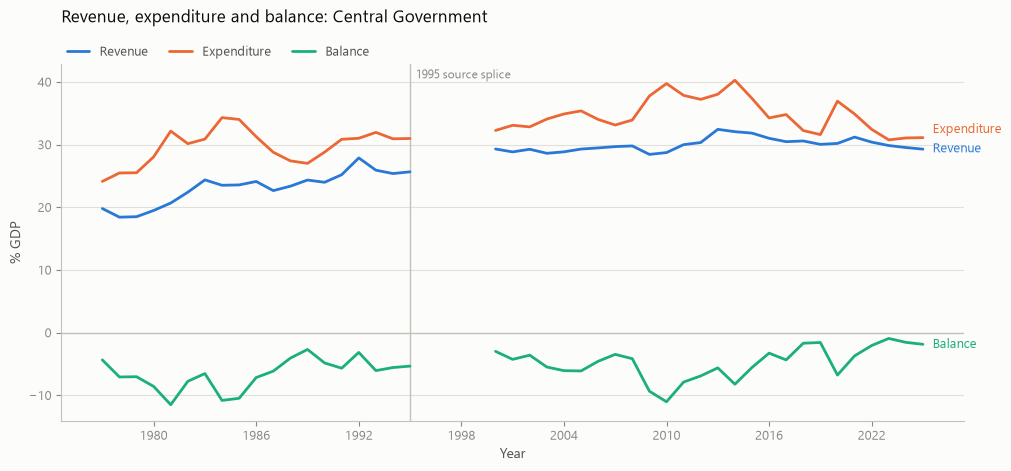

In [3]:
figure = figures.revenue_expenditure(accounts, 'central_government')

The line breaks at 1996-1999 because subsector components do not exist for those
years. The break is drawn deliberately: joining 1995 to 2000 would suggest a path
the sources do not contain.

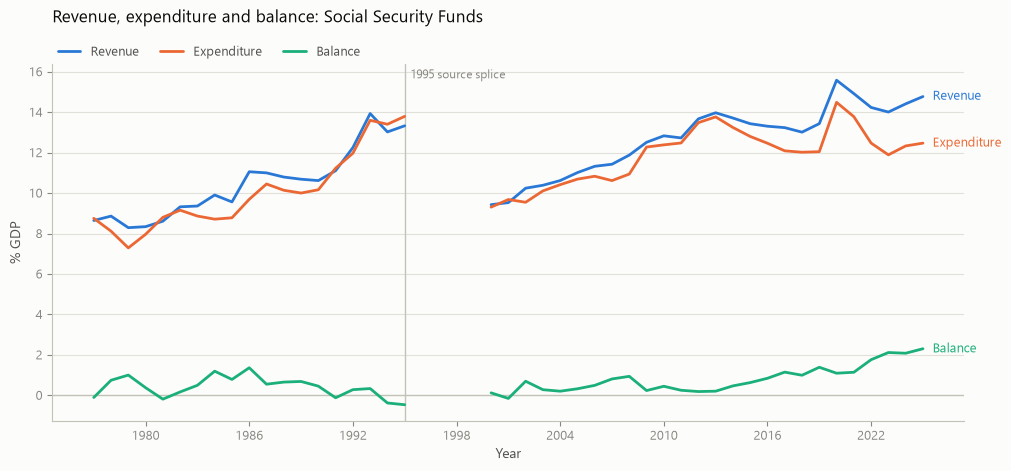

In [4]:
figure = figures.revenue_expenditure(accounts, 'social_security_funds')

## 2. Changes

Differencing the identity gives

$$\Delta B_{i,t} = \Delta R_{i,t} - \Delta E_{i,t},$$

which holds exactly for adjacent years inside a continuous source block. No
change is computed across the 1995-to-2000 subsector gap; those rows are dropped
rather than bridged.

In [5]:
ssf_changes = changes.loc[changes['sector'].eq('social_security_funds')]
display(ssf_changes.tail(10).round(1))
print('rows in the table:', len(changes))
print('year gaps present:', sorted(changes['year_gap'].dropna().unique().tolist()))

,year,sector,year_gap,revenue_change_m_eur,expenditure_change_m_eur,balance_change_m_eur,decomposition_error_m_eur
167,2016,social_security_funds,1,708.4,267.0,441.4,0.0
168,2017,social_security_funds,1,1076.9,404.3,672.6,0.0
169,2018,social_security_funds,1,798.2,1005.9,-207.8,0.0
170,2019,social_security_funds,1,2136.9,1196.3,940.7,0.0
171,2020,social_security_funds,1,2508.7,3286.2,-777.6,0.0
172,2021,social_security_funds,1,975.7,705.3,270.4,0.0
173,2022,social_security_funds,1,2427.2,596.1,1831.1,0.0
174,2023,social_security_funds,1,3143.0,1722.2,1420.8,0.0
175,2024,social_security_funds,1,3896.0,3585.6,310.4,0.0
176,2025,social_security_funds,1,3554.5,2520.4,1034.1,0.0


rows in the table: 177
year gaps present: [1]


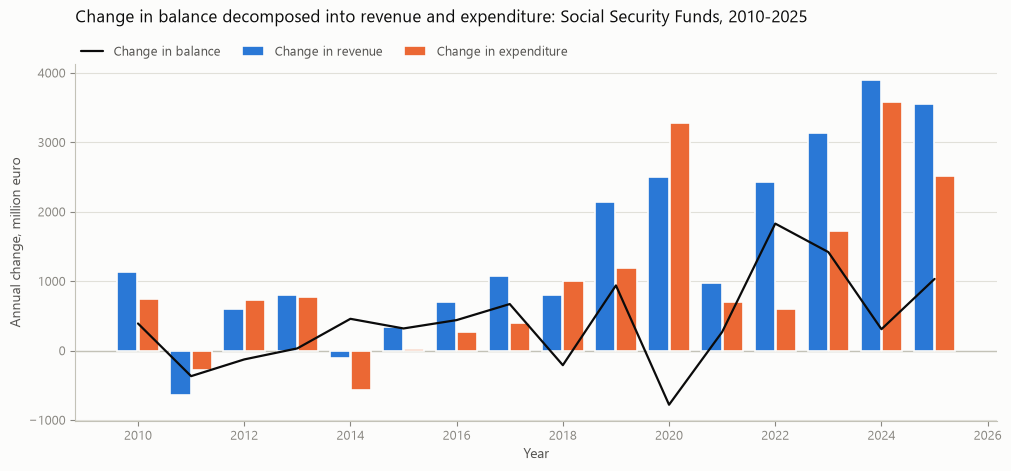

In [6]:
last_year = int(changes['year'].max())
figure = figures.revenue_expenditure_changes(
    changes, 'social_security_funds', start_year=2010, end_year=last_year
)

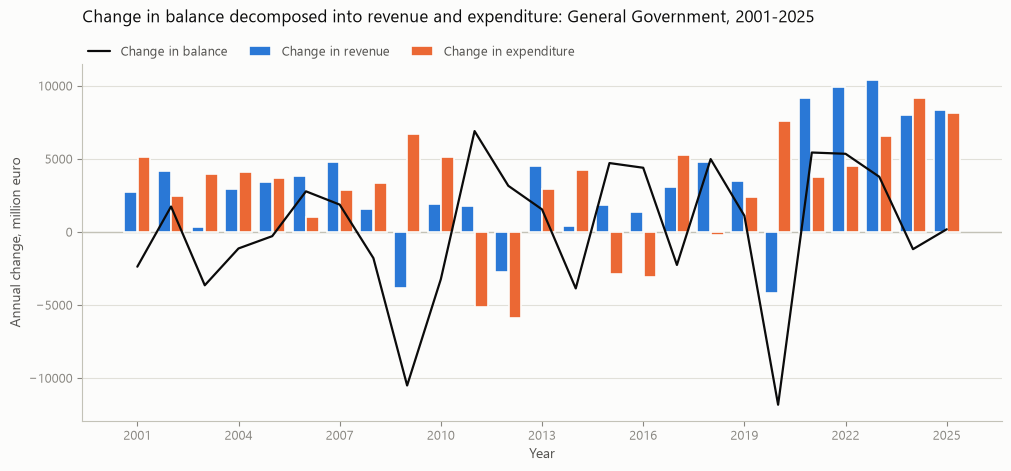

In [7]:
figure = figures.revenue_expenditure_changes(
    changes, 'general_government', start_year=2001, end_year=last_year
)

## 3. Which episodes were revenue-driven and which expenditure-driven?

The ranked episodes come from notebook 06, which selects them on the GDP-scaled
aggregate change. Here they are split into the revenue and expenditure movements
that composed them.

A balance improves when revenue rises faster than expenditure, so a positive
expenditure column alongside a positive balance change means expenditure grew but
grew less. The residual column is the gap between this account-panel measure of the
annual change and the canonical balance-panel measure of the same change: the two
come from different source families and are not forced to agree.

In [8]:
movements = pd.read_csv(TABLES / 'largest_balance_movements.csv')
display(
    movements[
        [
            'direction',
            'year',
            'account_balance_change_m_eur',
            'revenue_change_m_eur',
            'expenditure_change_m_eur',
            'source_family_difference_m_eur',
        ]
    ].round(1)
)

,direction,year,account_balance_change_m_eur,revenue_change_m_eur,expenditure_change_m_eur,source_family_difference_m_eur
0,improvement,2011,6913.1,1796.2,-5116.9,-0.1
1,improvement,2015,4725.5,1854.3,-2871.2,0.5
2,improvement,2021,5446.8,9188.3,3741.5,0.2
3,improvement,1986,633.5,2091.9,1458.4,0.0
4,improvement,2018,4996.7,4793.6,-203.2,0.3
5,deterioration,2009,-10495.9,-3801.8,6694.1,-0.1
6,deterioration,2020,-11812.9,-4176.5,7636.4,-0.1
7,deterioration,1981,-477.8,573.5,1051.3,0.0
8,deterioration,1984,-790.2,943.0,1733.2,0.0
9,deterioration,1980,-296.2,523.0,819.2,0.0


## 4. Decomposition check

The residual is an arithmetic identity check on the persisted table, so anything
other than numerical noise would indicate a defect.

In [9]:
print('max |decomposition residual| (M EUR):', float(changes['decomposition_error_m_eur'].abs().max()))
display(
    changes.groupby('sector')['decomposition_error_m_eur']
    .apply(lambda column: column.abs().max())
    .rename('max_abs_residual_m_eur')
    .to_frame()
)

max |decomposition residual| (M EUR): 5.456968211e-12


,max_abs_residual_m_eur
sector,
central_government,5.456968e-12
general_government,1.818989e-12
regional_local_government,4.831691e-13
social_security_funds,7.389644e-13


## Interpretation limits

1. A revenue or expenditure change is **not decomposed into policy and
   macroeconomic components**. Doing so requires assumptions this repository
   does not make.
2. Totals are used, so a change in revenue may reflect composition shifts that
   are visible only in the component columns of the account panel.
3. Changes are **never computed across a source gap**, which is why the modern
   subsector series begins contributing changes in 2001.

---

[Previous: 04. Long-run balance decomposition](04_balance_decomposition.ipynb) | [Next: 06. Year-to-year balance attribution](06_year_to_year_attribution.ipynb)

Every table shown above is also persisted as CSV, so results can be checked without reading notebook state. To rebuild everything from the bundled raw sources:

```bash
poetry install
make all
```